# <h1 style="color:#9bddff">Portfolio Optimization & Risk Profile Analytics</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import pandas as pd
import json
import commentjson
import commentjson
import os
import re
from urllib.parse import urlencode
import requests
import datetime
import logging
from pathlib import Path
import time

import yaml
from pathlib import Path
import itertools
import numpy as np
from typing import Dict, List, Any

import ipywidgets as ipw
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [3]:
from bloomberg.enterprise.oauth import (OAuthClient, EnvTier,
                                        OAuthDeviceModeConfig, OAuthServerModeConfig
                                        )

from bloomberg.enterprise.oauth.oauth_flows.oauth_user_mode import UserModeOauth
from bloomberg.enterprise.oauth.utils import _oauth_store

### Import Source Code

In [5]:
from src.api_config import (
    OPTIMIZATION_TRIGGER_ENDPOINT, RESULTS_RETRIEVAL_ENDPOINT,
    WORKFLOWS_PATH, WORKFLOW_RUNS_PATH,
    CATALOG_PATH, REPORT_PATH,
    CONNECTION_TEST_PATH, WAIT_TIME_SECONDS, 
    AUTH_CONFIG_PATH, get_authorization_headers, 
    test_connection, auth_manager
)
from src.config_loader import (
    load_optimization_config,
    generate_constraint_combinations,
    generate_risk_model_combinations,
    generate_all_parameter_combinations
)
from src.template_utils import (
    load_template, 
    populate_template, 
    load_constraint_mappings,
    load_goal_mappings,
    load_trade_universe_mappings,
    load_custom_instrument_list,
    map_constraint_to_params
)
from src.task_builder import build_task
from src.optimization_workflow import (
    register_optimization_tasks, build_optimization_request,
    get_optimization_response, run_pending_optimizations,
    generate_optimization_report, view_optimization_report
)
from src.optimization_tracker import OptimizationTracker
from src.analysis_utils import OptimizationAnalyzer
from src.workflow_manager import OptimizationWorkflowManager

from src.data_manager import OptimizationDataManager
from src.plot_manager import (ParallelCoordinatesPlotter, create_distribution_plot)
from src.gui import PortfolioOptimizationGUI

### Test API Connection

In [6]:
# Test API Connection
if test_connection():
    print('Connection is fine')
    # Continue with your application
else:
    print('Connection failed - please check credentials and network')
    # Handle the connection failure

Connection is fine


In [7]:
auth_manager.oauth_client

In [8]:
pd.set_option('display.max_columns', None)

### Optimization Workflow Configuration

##### Load Config (now handled by Workflow Manager for Registering Tasks)

In [9]:
config = load_optimization_config("config/optimization_parameters.yaml")

In [10]:
config

{'portfolios': ['EQUITY8_US', 'EQUITY8_MID_CAP_GROWTH'],
 'benchmarks': ['RAY', 'RDG', 'RLV'],
 'trade_universes': ['benchmark_buy_and_sell'],
 'portfolio_benchmark_pairs': [{'portfolio': 'EQUITY8_US', 'benchmark': 'RAY'},
  {'portfolio': 'EQUITY8_MID_CAP_GROWTH', 'benchmark': 'RDG'}],
 'portfolio_benchmark_universe_mappings': [{'portfolio': 'EQUITY8_US',
   'benchmark': 'RAY',
   'universes': ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']},
  {'portfolio': 'EQUITY8_MID_CAP_GROWTH',
   'benchmark': 'RDG',
   'universes': ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']}],
 'risk_options': [{'model': ['US_EQUITY']},
  {'scaling': ['YEAR']},
  {'horizon': ['ANNUAL']}],
 'goals': ['minimize_active_total_risk', 'maximize_custom_expected_return'],
 'constraints': {'turnover': {'min': 0.2, 'max': 0.5, 'step': 0.1},
  'maximum_positions': {'values': [200, 250, 300]},
  'active_total_risk': {'min': 0.02, 'max': 0.05, 'step': 0.01},
  'benchmark_sector_deviation': {'min': 0.05, 

In [11]:
config['portfolio_benchmark_universe_mappings']

[{'portfolio': 'EQUITY8_US',
  'benchmark': 'RAY',
  'universes': ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']},
 {'portfolio': 'EQUITY8_MID_CAP_GROWTH',
  'benchmark': 'RDG',
  'universes': ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']}]

##### Generate Constraint Combinations and Mappings (now handled by Workflow Manager for Registering Tasks)

In [12]:
constraint_combinations = generate_constraint_combinations(config)
risk_combinations = generate_risk_model_combinations(config)
all_combinations = generate_all_parameter_combinations(config)

constraint_mappings = load_constraint_mappings("config/constraint_mappings.yaml")
goal_mappings = load_goal_mappings("config/goal_mappings.yaml")
trade_universe_mappings = load_trade_universe_mappings("config/trade_universe_mappings.yaml")

In [13]:
all_combinations[-1]

{'optimization_id': 'opt_EQUITY8_MID_CAP_GROWTH_RDG_benchmark_buy_and_sell_active_ideas_buy_and_sell_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_5465970114088064939',
 'portfolio': 'EQUITY8_MID_CAP_GROWTH',
 'benchmark': 'RDG',
 'as_of_date': '2025-04-15',
 'risk_options': {'model': 'US_EQUITY',
  'scaling': 'YEAR',
  'horizon': 'ANNUAL'},
 'goals': ['minimize_active_total_risk', 'maximize_custom_expected_return'],
 'constraints': {'maximum_positions': 300,
  'max_security_weight': 0.05,
  'turnover': 0.5,
  'active_total_risk': 0.06,
  'benchmark_sector_deviation': 0.2},
 'universes': ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']}

In [14]:
print(f"Generated {len(all_combinations)} parameter combinations")

# Print the first combination
if all_combinations:
    print("\nExample parameter set:")
    for key, value in all_combinations[0].items():
        print(f"{key}: {value}")
        

Generated 960 parameter combinations

Example parameter set:
optimization_id: opt_EQUITY8_US_RAY_benchmark_buy_and_sell_active_ideas_buy_and_sell_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_2237953281451362195
portfolio: EQUITY8_US
benchmark: RAY
as_of_date: 2025-04-15
risk_options: {'model': 'US_EQUITY', 'scaling': 'YEAR', 'horizon': 'ANNUAL'}
goals: ['minimize_active_total_risk', 'maximize_custom_expected_return']
constraints: {'maximum_positions': 200, 'max_security_weight': 0.03, 'turnover': 0.2, 'active_total_risk': 0.02, 'benchmark_sector_deviation': 0.05}
universes: ['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']


In [15]:
config_params = all_combinations[-1]

In [16]:
config_params['universes']

['benchmark_buy_and_sell', 'active_ideas_buy_and_sell']

In [17]:
list(constraint_mappings.keys())

['maximum_positions',
 'turnover',
 'active_total_risk',
 'benchmark_sector_deviation',
 'max_security_weight']

In [18]:
goal_mappings

{'minimize_active_total_risk': {'template_path': 'goals/minimize_active_total_risk.json',
  'param_key': 'minimize_active_total_risk'},
 'maximize_custom_expected_return': {'template_path': 'goals/maximize_custom_expected_return.json',
  'param_key': 'maximize_custom_expected_return'}}

##### Build Task (now handled by Workflow Manager for Registering Tasks)

In [19]:
task = build_task(config_params, trade_universe_mappings, goal_mappings, constraint_mappings)

In [20]:
task['tradeUniverse']
#task['goals']
#task['portfolioConstraints']

[{'instrumentSource': {'id': 'RDG', 'type': 'INDEX_TICKER'},
  'tradingRule': 'BUY_AND_SELL',
  'useAsSecondaryBenchmark': False},
 {'instrumentSource': {'id': 'dummy', 'type': 'CUSTOM_UNIVERSE'},
  'tradingRule': 'BUY_AND_SELL',
  'useAsSecondaryBenchmark': False,
  'customUniverse': [{'instrumentUniqueId': 'EQ0010001500001000'},
   {'instrumentUniqueId': 'EQ0013224200001000'},
   {'instrumentUniqueId': 'EQ0010203200001000'},
   {'instrumentUniqueId': 'EQ0010035900001000'},
   {'instrumentUniqueId': 'EQ0010175800001000'},
   {'instrumentUniqueId': 'EQ0017904600001000'},
   {'instrumentUniqueId': 'EQ0010090500001000'},
   {'instrumentUniqueId': 'EQ0010089400001000'},
   {'instrumentUniqueId': 'EQ0031367300002000'},
   {'instrumentUniqueId': 'EQ0010097200001000'},
   {'instrumentUniqueId': 'EQ0010115800001000'},
   {'instrumentUniqueId': 'EQ0010137700001000'},
   {'instrumentUniqueId': 'EQ0010154800001000'},
   {'instrumentUniqueId': 'EQ0000000005089229'},
   {'instrumentUniqueId': 'EQ0

##### Build Request (now handled by Workflow Manager for executing optimizations)

In [21]:
opt_rec = build_optimization_request(task)

In [22]:
#opt_rec

### Initialize Tracker Object

In [184]:
# Create a tracker instance
tracker = OptimizationTracker()

# Register a single task
# optimization_id = tracker.register_optimization_task(task, task['optimizationId'])

# When you start running a single optimization, update its status
# tracker.update_optimization_status(
#     optimization_id=optimization_id,
#     status="running"
# )

# After the optimization completes, save the results
# tracker.save_optimization_results(
#     optimization_id=optimization_id,
#     opt_response=opt_res
# )

# results = tracker.load_optimization_results(optimization_id)

In [171]:
tracker.filter_optimizations(status="FAILED")

,optimization_id,fs_id,api_generated_id,portfolio,benchmark,as_of_date,risk_model,risk_scaling,risk_horizon,goals_summary,max_active_risk,min_positions,max_positions,min_turnover,max_turnover,min_sector_deviation,max_sector_deviation,min_security_weight,max_security_weight,task_path,results_path,summary_path,goals_path,constraints_path,trades_path,exceptions_path,risk_report_path,status,error_message,run_timestamp,session_id
45,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,c80daa8b19104661835c6c287243f43b,a3cc67d5-d12e-40be-b582-4d0cb2082646,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.05,25,200,0,0.3,-0.15,0.15,0.0,0.05,tasks\c80daa8b19104661835c6c287243f43b.json,data\optimization_results\c80daa8b19104661835c...,data\optimization_results\c80daa8b19104661835c...,data\optimization_results\c80daa8b19104661835c...,data\optimization_results\c80daa8b19104661835c...,data\optimization_results\c80daa8b19104661835c...,data\optimization_results\c80daa8b19104661835c...,data\risk_reports\c80daa8b19104661835c6c287243...,FAILED,'errorDescription',2025-04-19T21:15:54.904818,None
289,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,3cbf6bce8cd0554202d40403384d1e7f,0a2f7618-6db6-40f5-9b53-9bab86ec7684,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.03,25,200,0,0.5,-0.15,0.15,0.0,0.03,tasks\3cbf6bce8cd0554202d40403384d1e7f.json,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\risk_reports\3cbf6bce8cd0554202d40403384d...,FAILED,'errorDescription',2025-04-20T22:22:40.197654,None
346,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,9ee44e4e0a03da8750f393a72f50a7e0,0c141f8f-6caf-4f9f-838a-4f690d8a241a,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.02,25,250,0,0.3,-0.10,0.10,0.0,0.03,tasks\9ee44e4e0a03da8750f393a72f50a7e0.json,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\risk_reports\9ee44e4e0a03da8750f393a72f50...,FAILED,'errorDescription',2025-04-21T00:23:07.531173,None
493,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,c2fbd804aee5b4c806173dfdc0eb7304,babdd882-abb1-4e6e-ad7b-4ea699126f40,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.05,25,300,0,0.5,-0.15,0.15,0.0,0.05,tasks\c2fbd804aee5b4c806173dfdc0eb7304.json,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\risk_reports\c2fbd804aee5b4c806173dfdc0eb...,FAILED,'errorDescription',2025-04-21T16:31:15.198971,None
644,opt_EQUITY8_MID_CAP_GROWTH_RDG_benchmark_buy_a...,cf2a8ebb6855eaaee8ed678ee45590b2,28943a3c-03f6-4939-9b7a-761230d87ee3,EQUITY8_MID_CAP_GROWTH,RDG,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.06,25,250,0,0.4,-0.10,0.10,0.0,0.05,tasks\cf2a8ebb6855eaaee8ed678ee45590b2.json,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\risk_reports\cf2a8ebb6855eaaee8ed678ee455...,FAILED,'errorDescription',2025-04-21T20:49:23.958213,None


In [185]:
pd.DataFrame(tracker.get_failed_optimizations())

,optimization_id,fs_id,api_generated_id,portfolio,benchmark,as_of_date,risk_model,risk_scaling,risk_horizon,goals_summary,max_active_risk,min_positions,max_positions,min_turnover,max_turnover,min_sector_deviation,max_sector_deviation,min_security_weight,max_security_weight,task_path,results_path,summary_path,goals_path,constraints_path,trades_path,exceptions_path,risk_report_path,status,error_message,run_timestamp,session_id
0,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,3cbf6bce8cd0554202d40403384d1e7f,0a2f7618-6db6-40f5-9b53-9bab86ec7684,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.03,25,200,0,0.5,-0.15,0.15,0.0,0.03,tasks\3cbf6bce8cd0554202d40403384d1e7f.json,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\optimization_results\3cbf6bce8cd0554202d4...,data\risk_reports\3cbf6bce8cd0554202d40403384d...,FAILED,'errorDescription',2025-04-20T22:22:40.197654,None
1,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,9ee44e4e0a03da8750f393a72f50a7e0,0c141f8f-6caf-4f9f-838a-4f690d8a241a,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.02,25,250,0,0.3,-0.10,0.10,0.0,0.03,tasks\9ee44e4e0a03da8750f393a72f50a7e0.json,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\optimization_results\9ee44e4e0a03da8750f3...,data\risk_reports\9ee44e4e0a03da8750f393a72f50...,FAILED,'errorDescription',2025-04-21T00:23:07.531173,None
2,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,c2fbd804aee5b4c806173dfdc0eb7304,babdd882-abb1-4e6e-ad7b-4ea699126f40,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.05,25,300,0,0.5,-0.15,0.15,0.0,0.05,tasks\c2fbd804aee5b4c806173dfdc0eb7304.json,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\optimization_results\c2fbd804aee5b4c80617...,data\risk_reports\c2fbd804aee5b4c806173dfdc0eb...,FAILED,'errorDescription',2025-04-21T16:31:15.198971,None
3,opt_EQUITY8_MID_CAP_GROWTH_RDG_benchmark_buy_a...,cf2a8ebb6855eaaee8ed678ee45590b2,28943a3c-03f6-4939-9b7a-761230d87ee3,EQUITY8_MID_CAP_GROWTH,RDG,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.06,25,250,0,0.4,-0.10,0.10,0.0,0.05,tasks\cf2a8ebb6855eaaee8ed678ee45590b2.json,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\optimization_results\cf2a8ebb6855eaaee8ed...,data\risk_reports\cf2a8ebb6855eaaee8ed678ee455...,FAILED,'errorDescription',2025-04-21T20:49:23.958213,None
4,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,b36b572e3ba41ac0f9015ddb3fd77a5d,68135b6a-072e-4bd0-aece-1c049e1cdd03,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.04,25,200,0,0.2,-0.20,0.20,0.0,0.03,tasks\b36b572e3ba41ac0f9015ddb3fd77a5d.json,data\optimization_results\b36b572e3ba41ac0f901...,data\optimization_results\b36b572e3ba41ac0f901...,data\optimization_results\b36b572e3ba41ac0f901...,data\optimization_results\b36b572e3ba41ac0f901...,data\optimization_results\b36b572e3ba41ac0f901...,data\optimization_results\b36b572e3ba41ac0f901...,data\risk_reports\b36b572e3ba41ac0f9015ddb3fd7...,FAILED,'errorDescription',2025-04-21T22:50:22.208521,None
5,opt_EQU

### Initialize Workflow Manager

In [179]:
def get_dir_size(path):
    """Get directory size using pathlib"""
    return sum(f.stat().st_size for f in Path(path).glob('**/*') if f.is_file())

dir_path = "data"
size_bytes = get_dir_size(dir_path)
print(f"Size in bytes: {size_bytes}")
print(f"Size in MB: {size_bytes / (1024 * 1024):.2f} MB")

Size in bytes: 517312975
Size in MB: 493.35 MB


In [181]:
workflow_mngr = OptimizationWorkflowManager()

In [182]:
workflow_mngr.run_workflow(
    register=False, # Register any new optimization tasks
    run=True, # Run Pending Optimizations
    status='FAILED',
    max_runs=1,
    generate_report=False, # Generate a Report
    show_report=False # Show the Report
)

Running pending optimizations...
Running optimization: opt_EQUITY8_US_RAY_benchmark_buy_and_sell_active_ideas_buy_and_sell_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_-8424265373813910689
{'portfolio': {'id': 'EQUITY8_US', 'type': 'PORTFOLIO_NAME'}, 'benchmark': {'id': 'RAY', 'type': 'INDEX_TICKER'}, 'tradeUniverse': [{'instrumentSource': {'id': 'RAY', 'type': 'INDEX_TICKER'}, 'tradingRule': 'BUY_AND_SELL', 'useAsSecondaryBenchmark': False}, {'instrumentSource': {'id': 'dummy', 'type': 'CUSTOM_UNIVERSE'}, 'tradingRule': 'BUY_AND_SELL', 'useAsSecondaryBenchmark': False, 'customUniverse': [{'instrumentUniqueId': 'EQ0010001500001000'}, {'instrumentUniqueId': 'EQ0013224200001000'}, {'instrumentUniqueId': 'EQ0010203200001000'}, {'instrumentUniqueId': 'EQ0010035900001000'}, {'instrumentUniqueId': 'EQ0010175800001000'}, {'instrumentUniqueId': 'EQ0017904600001000'}, {'instrumentUniqueId': 'EQ0010090500001000'}, {'instrumentUniqueId': 'EQ001008940

In [180]:
opt_id = "opt_EQUITY8_US_RAY_benchmark_buy_and_sell_active_ideas_buy_and_sell_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_-5373207630569483223"
workflow_mngr.tracker.filter_optimizations(optimization_id=opt_id)

,optimization_id,fs_id,api_generated_id,portfolio,benchmark,as_of_date,risk_model,risk_scaling,risk_horizon,goals_summary,max_active_risk,min_positions,max_positions,min_turnover,max_turnover,min_sector_deviation,max_sector_deviation,min_security_weight,max_security_weight,task_path,results_path,summary_path,goals_path,constraints_path,trades_path,exceptions_path,risk_report_path,status,error_message,run_timestamp,session_id
897,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,7d0ed72f75840d25df6eff599217a496,69669be6-5740-4bbb-9fca-e973dee296be,EQUITY8_US,RAY,2025-04-15,US_EQUITY,YEAR,ANNUAL,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,0.02,25,300,0,0.2,-0.2,0.2,0.0,0.03,tasks\7d0ed72f75840d25df6eff599217a496.json,data\optimization_results\7d0ed72f75840d25df6e...,data\optimization_results\7d0ed72f75840d25df6e...,data\optimization_results\7d0ed72f75840d25df6e...,data\optimization_results\7d0ed72f75840d25df6e...,data\optimization_results\7d0ed72f75840d25df6e...,data\optimization_results\7d0ed72f75840d25df6e...,data\risk_reports\7d0ed72f75840d25df6eff599217...,success,None,2025-04-22T09:42:40.499000,POPAPI-54346fb8-8aa4-41b0-a77f-617d0bc89c02


In [164]:
frame = workflow_mngr.tracker.get_successful_optimizations()

In [165]:
frame.shape

(1208, 31)

In [166]:
len(workflow_mngr.tracker.get_pending_optimizations())

0

In [168]:
#pd.DataFrame(workflow_mngr.tracker.get_pending_optimizations()).groupby('portfolio').count()

In [161]:
analyzer = OptimizationAnalyzer(workflow_mngr.tracker)

### View Optimization Results

In [81]:
opt_results = tracker.load_optimization_results(executed_ids[-1])

In [82]:
goals_df = opt_results['goals']
goals_df

,fieldCode,initialValue,finalValue
0,active_total_risk,0.046348,0.007092
1,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),0.021758,0.050392


In [83]:
opt_results["constraints"]

,fieldCode,scopeType,initialValue,finalValue,classificationNode
0,maximum_positions,INITIAL_PORTFOLIO,1275.000000,200.000000,
1,turnover,INITIAL_PORTFOLIO,NaN,0.733862,
2,active_total_risk,INITIAL_PORTFOLIO,0.046348,0.007092,
3,weight,GROUP_CLASSIFICATION,0.000000,0.000000,GICS Sector:All


In [106]:
opt_results["summary"]

,turnoverRate,tradesValue,buyNumber,buyAmount,buyCost,sellNumber,sellAmount,sellCost
0,0.733862,9.927272e+07,124,4.864603e+07,0,1095,5.062669e+07,0


In [108]:
opt_results["trades"].head()

,instrumentUniqueId,ticker,instrumentName,initialWeight,finalWeight,changedWeight,changedQuantity,changedAmount,transactionCost
752,AAPL US,AAPL US,APPLE INC,0.000000,0.050000,0.050000,"{'type': 'UNITS', 'value': 33460.5566}",6.763717e+06,0
1120,NVDA US,NVDA US,NVIDIA CORP,0.008984,0.050000,0.041016,"{'type': 'UNITS', 'value': 49451.1203}",5.548416e+06,0
101,META US,META US,META PLATFORMS INC-CLASS A,0.007616,0.022553,0.014938,"{'type': 'UNITS', 'value': 3874.5861}",2.020674e+06,0
1219,USD,USD,US DOLLAR,-0.011863,0.002779,0.014642,"{'type': 'UNITS', 'value': 1980663.6235}",1.980664e+06,0
1081,AMZN US,AMZN US,AMAZON.COM INC,0.019710,0.033281,0.013571,"{'type': 'UNITS', 'value': 10222.132}",1.835793e+06,0


### Optimization Run Analysis

In [84]:
analyzer = OptimizationAnalyzer(tracker)

In [85]:
tracker.index_df.head(3).T

,0,1,2
optimization_id,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...
fs_id,cfeddfc8bd65c0c464af70168ebc2264,99db920a19d14699fbf18ee9f6cf9506,d19ee729c2f8ebf38379e781acb1dac9
api_generated_id,7034e7c1-4d67-4210-9a9a-e0b35d26d865,9d78db74-1608-41ff-b6ef-07ad4484ca0b,c7fd36de-3a5d-4a39-aa4f-b3fcb2a15044
portfolio,EQUITY8_US,EQUITY8_US,EQUITY8_US
benchmark,RAY,RAY,RAY
as_of_date,2025-04-15,2025-04-15,2025-04-15
risk_model,US_EQUITY,US_EQUITY,US_EQUITY
risk_scaling,YEAR,YEAR,YEAR
risk_horizon,ANNUAL,ANNUAL,ANNUAL
goals_summary,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...,active_total_risk:MINIMIZE:1;CUSTOM_NUMBER(FIE...


In [34]:
sensitivity_frame, sensitivity_frame_agg = analyzer.constraint_sensitivity_analysis(
    constraint_name="max_turnover",
)

In [35]:
sensitivity_frame.head()

,optimization_id,portfolio,benchmark,as_of_date,constraint_name,constraint_value,goal_name,goal_metric,goal_value
0,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,max_turnover,0.2,active_total_risk,finalValue,0.013568
1,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,max_turnover,0.2,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),finalValue,0.047209
2,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,max_turnover,0.2,active_total_risk,finalValue,0.013568
3,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,max_turnover,0.2,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),finalValue,0.047209
4,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,max_turnover,0.2,active_total_risk,finalValue,0.013568


In [37]:
sorted(sensitivity_frame['constraint_value'].unique())

array([0.2, 0.3, 0.4, 0.5])

In [38]:
frame = sensitivity_frame.loc[sensitivity_frame['goal_name'] == 'active_total_risk'].copy()

In [98]:
from src.plot_manager import create_distribution_plot

In [115]:
# Combined plot with custom colors
custom_colors = {
    'box': {'marker': 'rgb(0,100,80)', 'line': 'rgb(0,100,80)'},
    'violin': {'line': 'rgb(180,60,0)', 'fill': 'rgb(180,60,0)'}
}

fig = create_distribution_plot(
    df=frame,
    x_column='constraint_value',
    y_column='goal_value',
    plot_type='combined',
    title='Distribution of Goal Values by Turnover',
    y_axis_title='Active Total Risk',
    #color_scheme=custom_colors,
    jitter=0.3,
    show_points=False,
    custom_layout={'legend_title_text': 'Turnover Constraint'}
)
fig.show()

In [88]:
sensitivity_frame_agg.T

,0,1
constraint_value,,
portfolio,EQUITY8_US,EQUITY8_US
benchmark,RAY,RAY
as_of_date,2025-04-15,2025-04-15
goal_name,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),active_total_risk
0.2,0.050212,0.010423
0.3,0.049258,0.012198
0.4,0.053807,0.013377
0.5,0.056006,0.013245


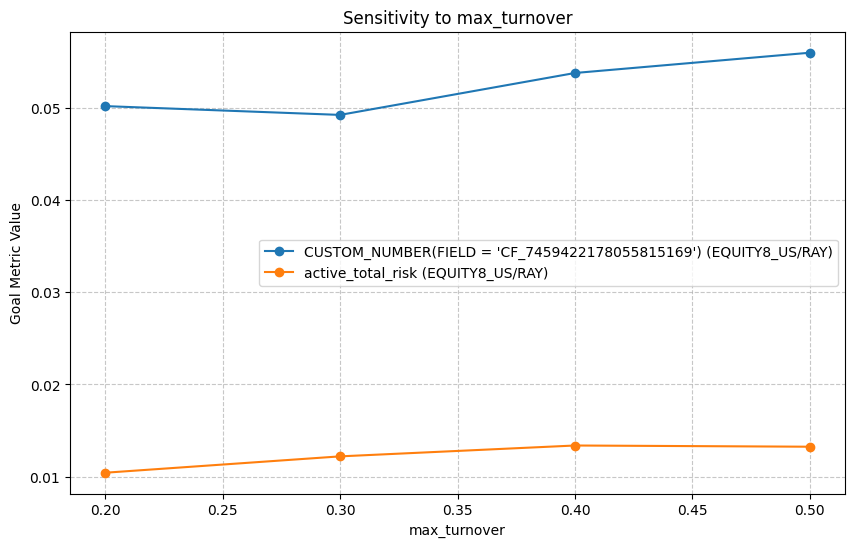

In [89]:
analyzer.plot_constraint_sensitivity(
    constraint_name="max_turnover"
)

In [99]:
opt_comp_frame = analyzer.compare_optimizations(executed_ids, 'goals')
# opt_comp_frame = analyzer.compare_optimizations(executed_ids, 'constraints')
# opt_comp_frame = analyzer.compare_optimizations(executed_ids, 'trades')
# opt_comp_frame = analyzer.compare_optimizations(executed_ids, 'summary')

In [100]:
opt_comp_frame.head()

,optimization_id,portfolio,benchmark,as_of_date,goal_name,max_active_risk,min_positions,max_positions,min_turnover,max_turnover,min_sector_deviation,max_sector_deviation,min_security_weight,max_security_weight,goal_initialValue,goal_finalValue
0,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,active_total_risk,0.03,25,200,0,0.2,-0.10,0.10,0.0,0.05,0.046348,0.007309
1,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),0.03,25,200,0,0.2,-0.10,0.10,0.0,0.05,0.021758,0.047275
2,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,active_total_risk,0.03,25,200,0,0.2,-0.15,0.15,0.0,0.05,0.046348,0.007309
3,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169'),0.03,25,200,0,0.2,-0.15,0.15,0.0,0.05,0.021758,0.047275
4,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,active_total_risk,0.04,25,200,0,0.2,-0.10,0.10,0.0,0.05,0.046348,0.007206


In [101]:
top_constraints_frame = analyzer.find_optimal_constraints(
    target_goal="active_total_risk",
    optimize_direction="minimize"
)

In [103]:
top_constraints_frame.head()

,optimization_id,portfolio,benchmark,as_of_date,goal_value,max_active_risk,min_positions,max_positions,min_turnover,max_turnover,min_sector_deviation,max_sector_deviation,min_security_weight,max_security_weight
40,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,0.007092,0.03,25,200,0,0.3,-0.10,0.10,0.0,0.05
41,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,0.007092,0.03,25,200,0,0.3,-0.15,0.15,0.0,0.05
34,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,0.007206,0.04,25,200,0,0.2,-0.10,0.10,0.0,0.05
35,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,0.007206,0.04,25,200,0,0.2,-0.15,0.15,0.0,0.05
39,opt_EQUITY8_US_RAY_benchmark_buy_and_sell_acti...,EQUITY8_US,RAY,2025-04-15,0.007297,0.06,25,200,0,0.2,-0.15,0.15,0.0,0.05


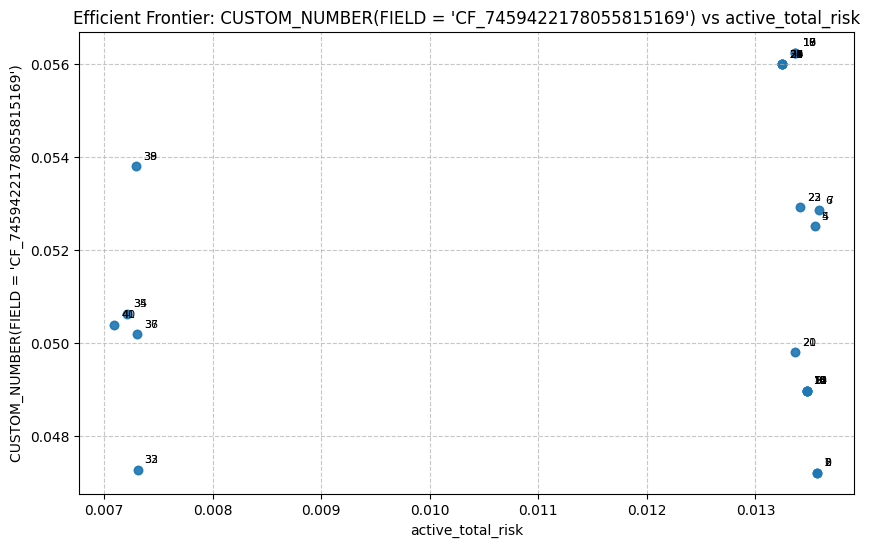

In [105]:
frontier_frame = analyzer.calculate_efficient_frontier(
    x_goal="active_total_risk",
    y_goal="CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169')",
    plot=True
)

### Generate and View an Optimization Report

In [355]:
# Generate a report
print("Generating optimization report...")
report_file = generate_optimization_report(
    tracker=tracker,
    filters={"status":"success"}
)
print(f"Report generated at: {report_file}")

Generating optimization report...
Report generated at: optimization_report.html


In [357]:
# View the report
view_optimization_report(tracker, report_file)

'c:\\Users\\lescobar20\\Desktop\\amer_ebg\\montreal_spotlight - Copy\\optimization_report.html'

### Plot Optimization Iterations

In [12]:
from src.data_manager import OptimizationDataManager
from src.plot_manager import ParallelCoordinatesPlotter
from src.gui import PortfolioOptimizationGUI

In [17]:
optimization_ids = list(frame['optimization_id'])

custom_goal_mapper = {
    "CUSTOM_NUMBER(FIELD = 'CF_7459422178055815169')": "expected_return"
}
metadata_constraint_mapper = {
        ('weight', 'GICS Sector:All'): 'max_sector_deviation'
    }


In [27]:
data_manager = OptimizationDataManager(results_frame)

In [28]:
#data_manager.frame

In [29]:
gui = PortfolioOptimizationGUI(data_manager)

In [31]:
gui.view

### Testing

In [364]:
# %%time
# opt_res = get_optimization_response(
#     auth_headers=get_authorization_headers(),
#     optimization_request=opt_req
# )

In [65]:
def extract_optimization_id_from_path(task_file_path):
    """
    Extract the optimization ID from a task file path.
    
    Args:
        task_file_path: Path to the task JSON file
        
    Returns:
        Optimization ID (filename without extension)
    """
    # Convert to Path object
    path = Path(task_file_path)
    
    # Get just the filename without extension
    optimization_id = path.stem
    
    return optimization_id

In [60]:
task['optimizationId']

'opt_EQUITY8_MID_CAP_GROWTH_RDG_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_4500053229457978245'

In [66]:
optimization_id = extract_optimization_id_from_path(task['optimizationId'])
optimization_id

'opt_EQUITY8_MID_CAP_GROWTH_RDG_2025-04-15_US_EQUITY_YEAR_ANNUAL_minimize_active_total_risk_maximize_custom_expected_return_4500053229457978245'

In [67]:
task['optimizationId'] == optimization_id

True